In [15]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.datasets import make_blobs

In [16]:
x,y=make_blobs(n_samples=1000,centers=3,n_features=2)

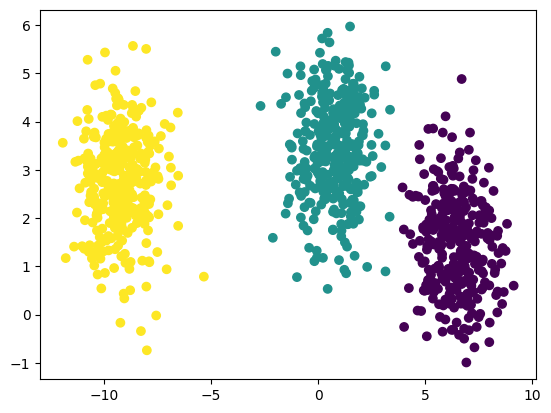

In [17]:
plt.scatter(x[:,0],x[:,1],c=y)

In [18]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=32)

In [19]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
xtrain=sc.fit_transform(xtrain)
xtest=sc.transform(xtest)

In [20]:
from sklearn.cluster import KMeans

In [21]:
#Elbow method for k value
wcss=[]
for k in range(1,11):
    Kmeans=KMeans(n_clusters=k,init='k-means++')
    Kmeans.fit(xtrain)
    wcss.append(Kmeans.inertia_)

In [22]:
wcss

[1400.0000000000005,
 691.4214488575552,
 355.99938748864474,
 274.1546594460359,
 188.63676350023573,
 142.75809877700848,
 118.50051889728499,
 101.46816845907972,
 87.02669928182095,
 77.61535538950592]

([<matplotlib.axis.XTick at 0x217151a2a10>,
 [Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

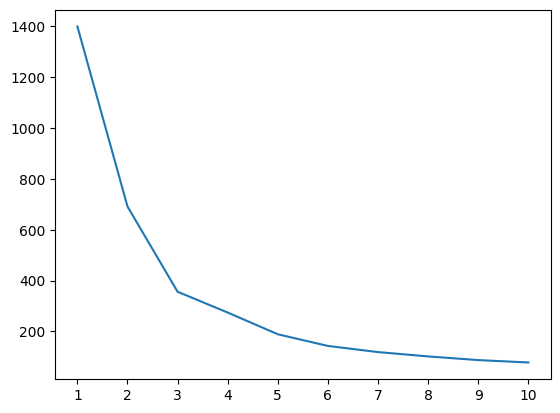

In [23]:
plt.plot(range(1,11),wcss)
plt.xticks(range(1,11))


In [24]:
Kmeans=KMeans(n_clusters=3,init='k-means++')
Kmeans.fit_predict(xtrain)

array([1, 1, 2, 2, 1, 0, 1, 2, 2, 0, 1, 0, 0, 0, 0, 0, 1, 2, 1, 2, 1, 1,
       2, 0, 2, 2, 0, 2, 2, 1, 2, 2, 2, 2, 2, 0, 1, 2, 1, 0, 0, 0, 2, 1,
       2, 0, 1, 1, 2, 0, 0, 2, 2, 1, 2, 2, 0, 2, 1, 1, 0, 1, 0, 1, 0, 1,
       1, 1, 2, 0, 0, 1, 2, 0, 2, 2, 2, 2, 0, 2, 1, 0, 2, 1, 2, 1, 2, 0,
       2, 2, 2, 2, 1, 2, 1, 0, 2, 1, 1, 2, 0, 1, 2, 1, 0, 2, 2, 0, 2, 1,
       2, 1, 2, 1, 2, 1, 0, 2, 1, 1, 1, 1, 2, 1, 0, 2, 2, 2, 2, 0, 1, 2,
       2, 1, 0, 0, 2, 0, 0, 2, 0, 2, 2, 1, 2, 1, 1, 1, 0, 1, 1, 2, 0, 1,
       2, 1, 2, 2, 1, 0, 2, 1, 2, 2, 1, 1, 1, 2, 1, 2, 2, 0, 1, 1, 2, 1,
       2, 1, 1, 2, 0, 2, 0, 2, 0, 2, 0, 0, 2, 0, 0, 2, 2, 1, 0, 2, 2, 1,
       2, 0, 0, 2, 1, 1, 2, 1, 1, 2, 1, 2, 1, 2, 0, 2, 0, 1, 1, 1, 0, 2,
       2, 1, 0, 2, 0, 2, 2, 2, 1, 2, 2, 2, 0, 1, 1, 1, 1, 0, 0, 2, 2, 0,
       0, 1, 1, 0, 1, 1, 2, 1, 2, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 0, 2, 1, 0, 2, 2, 1, 2, 2, 0, 0, 2, 2, 2, 2, 2, 0, 0, 1, 0, 0,
       2, 2, 2, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 2, 2,

In [25]:
ypred=Kmeans.predict(xtest)

In [ ]:
#Validating k value
#Kneelocator
#Silhoutee scoring

In [26]:
pip install kneed

Note: you may need to restart the kernel to use updated packages.


In [29]:
from kneed import KneeLocator

# Suppose wcss is already calculated for clusters 1 to 10
kl = KneeLocator(
    x=range(1, 11),   # number of clusters
    y=wcss,           # WCSS values
    curve='convex',
    direction='decreasing'
)

print("Elbow at cluster:", kl.knee)

Elbow at cluster: 3


In [30]:
silhouette_coeff=[]
from sklearn.metrics import silhouette_score
for k in range(2,11):
    Kmeans=KMeans(n_clusters=k,init='k-means++')
    Kmeans.fit(xtrain)
    score=silhouette_score(xtrain,Kmeans.labels_)
    silhouette_coeff.append(score)
silhouette_coeff

[0.46622880473245426,
 0.5383052344052202,
 0.47536251220903997,
 0.4733711741465289,
 0.4724201932686703,
 0.4574081673476704,
 0.46420218967171656,
 0.4495866632234502,
 0.44229420421103277]

([<matplotlib.axis.XTick at 0x21714eaf040>,
 [Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10')])

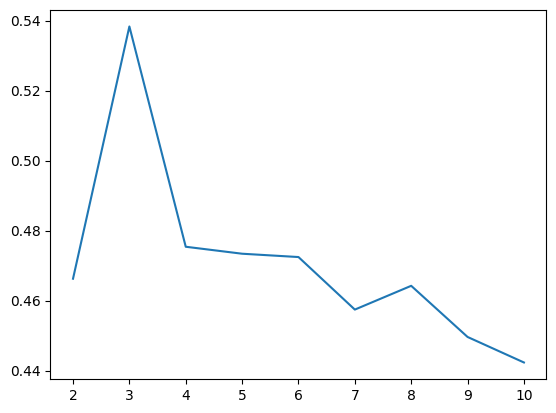

In [31]:
plt.plot(range(2,11),silhouette_coeff)
plt.xticks(range(2,11))